# WGAN_GP 
Andrew E. Davidson aedavids@ucsc.edu 8/29/24  

Copyright (c) 2020-2023, Regents of the University of California All rights reserved.   https://polyformproject.org/licenses/noncommercial/1.0.0

The purpose of this notebook is to ensure our pytorch implemention is correct. Our test generator learns to create points on a parabola. We have an infintes number of real training examples and can easily verify the results with a simple plot.

Most GANS traning the discriminator using a binary cross entropy loss function. This forces the discriminator to output either zero or one. This can lead to mode collapse and vanishing gradients.

We replaced the discriminator in basicPytorchGAN.ipynb with a Wasserstein critic and loss.  The Wasserstein loss is unbounded and based on the "Earth Mover's Distance". The norm of the gradient of the Wasserstein critic must be  1-Lipschitz continuous. This insures the it is differentiable and grows linearly. This contraint is implemented using a penality term on the gradient.

$$\begin{equation}
L = \mathbb{E}_{\tilde{x} \sim \mathbb{P}_g} [C(\tilde{x})] - \mathbb{E}_{x \sim \mathbb{P}_r} [C(G(z))] + \lambda \, \mathbb{E}_{\hat{x} \sim \mathbb{P}_{\hat{x}}} \left[ \left(\|\nabla_{\hat{x}} C(\hat{x})\|_2 - 1\right)^2 \right]
\end{equation}
$$

Where:
* L is the loss
* $\mathbb{E}$ is the Expected value function
* C(x) is the critic
* G(z) is the generator
* z is the noise vector
* $\lambda$ is the graient penality coefficient
* $\hat{x}$ is a generated example
* $\tilde{x}$ is a real example

**ref:**  
- [Wasserstein GAN](https://arxiv.org/abs/1701.07875)
- [Improved Training of Wasserstein GANs](https://arxiv.org/abs/1704.00028)
- [pytorch doc](https://pytorch.org/docs/stable/index.html)
- basicPytorchGAN.ipynb

installed following to get rid of warning
```
https://ipywidgets.readthedocs.io/en/stable/user_install.html
conda install -c conda-forge jupyterlab_widgets
conda install -c conda-forge ipywidgets

/private/home/aedavids/miniconda3/envs/extraCellularRNA/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
```

In [1]:
import ipynbname
import matplotlib.pyplot as plt

from numpy import hstack
from numpy import zeros
from numpy import ones
import psutil # provides process stats
from numpy.random import rand
from numpy.random import randn
import os

# by default keras use tensorflow as backend
import torch
print(f'torch.__version__: {torch.__version__}')

from torch import nn
torch.manual_seed(0) # Set for testing purposes, please do not change!

# tqdm provides progress bars for loops and iterables.
from tqdm.auto import tqdm

# class that helps you efficiently load and iterate over your dataset
# during training or inference
# we do not need this for our toy example
from torch.utils.data import DataLoader

notebookName = ipynbname.name()
notebookPath = ipynbname.path()
notebookDir = os.path.dirname(notebookPath)

outDir = f'{notebookDir}/{notebookName}.out'
imgOut = f'{outDir}/img'
os.makedirs(imgOut, exist_ok=True) 
print(f'imgOut:\n{imgOut}')

torch.__version__: 2.5.1.post102
imgOut:
/private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img


## Create models

In [2]:
class ParabolaGenerator( nn.Module ):
    def __init__( self, latentDim : int, nOutputs : int = 2 ) :
        '''
        arguments:
            latentDim: the length of the noise input vector

            nOutputs : the length of the output layers vector. Default = 2
        '''
        super().__init__()


        # keras
        # model.add(Dense(15, activation='relu', kernel_initializer='he_uniform', input_dim=latent_dim))
        # model.add(Dense(n_outputs, activation='linear'))
        
        self.model = nn.Sequential(
            nn.Linear(latentDim, 15),
            nn.ReLU(),
            nn.Linear(15, nOutputs),
        )
        # Initialize weights
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)
        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='linear')
        nn.init.zeros_(self.model[2].bias)

    def forward( self, noise : torch.Tensor ):
        '''
            noise should be the value returned by generateLatentPoints()
        '''
        ret = self.model( noise )
        return ret

In [3]:
class ParabolaCritic( nn.Module ):
    def __init__( self, inputSize : int = 2 ):
        '''
            inputSize, the length of the generated vectors
        '''
        super().__init__()

        # keras
        # model = Sequential()
    	# model.add(Dense(25, activation='relu', kernel_initializer='he_uniform', input_dim=n_inputs))
    	# model.add(Dense(1, activation='sigmoid'))
        
        self.model = nn.Sequential(
            nn.Linear(inputSize, 25),
            nn.ReLU(),
            nn.Linear(25, 1),
            nn.Sigmoid()
        )
        
        # Initialize weights
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)
        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='sigmoid')
        nn.init.zeros_(self.model[2].bias)

    def forward( self, X : torch.Tensor ):
        ret = self.model( X )
        return ret

def testParabolaCritic() :
    inputSize = 2
    discriminator = ParabolaCritic( inputSize )
    numTest = 2
    testInput = torch.randn( numTest, inputSize )
    predictions = discriminator( testInput )
    print(f'\npredictions :\n{predictions}')

testParabolaCritic()


predictions :
tensor([[0.5380],
        [0.5828]], grad_fn=<SigmoidBackward0>)


## Data Utilities
function to generate real and fake tensors

In [4]:
def generateRealSamples( n : int, device : str = 'cpu' ) -> tuple[torch.Tensor, torch.Tensor] :
    '''
    generate n real parabola samples with class labels

    arguments :
        n : number of examples to generated

        device. either 'cpu' or 'cuda', default 'cpu'

    Returns 2 Tensor
        X, y i.e. (realSamples, realLabels)

        y = 1, ie real
    '''
    # generate inputs in range [-0.5, 0.5]
    X1 = rand(n) - 0.5
    
    # generate outputs X^2
    X2 = X1 * X1
    
    # stack arrays
    X1 = X1.reshape(n, 1)
    X2 = X2.reshape(n, 1)
    X = hstack((X1, X2))
    
    # generate class labels
    y = ones((n, 1))

    # numpy dtype defaults to float64
    # pytorch default is float32
    realSamples = torch.tensor( X, dtype=torch.float32 ).to( device )
    realLabels = torch.tensor( y, dtype=torch.float32 ).to( device )
    
    return (realSamples, realLabels)

def testGenerateRealSamples() :
    X, y = generateRealSamples( n = 5 ) 
    print(f'X.device : {str(X.device)}')
    print( f'X.shape: {X.shape} rank : {len(X.shape)} num elements : {X.numel()}' )
    print( X )

    print(f'\ny.device : {str(y.device)}')
    print( f'y.shape: {y.shape} rank : {len(y.shape)} num elements : {y.numel()}' )
    print ( y) 

testGenerateRealSamples()

X.device : cpu
X.shape: torch.Size([5, 2]) rank : 2 num elements : 10
tensor([[ 0.4531,  0.2053],
        [ 0.2508,  0.0629],
        [ 0.2123,  0.0451],
        [ 0.0383,  0.0015],
        [-0.3041,  0.0925]])

y.device : cpu
y.shape: torch.Size([5, 1]) rank : 2 num elements : 5
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [5]:
def generateLatentPoints(latentDimensions : int = 5, 
                         n : int = 100, device : str = 'cpu' ) -> torch.Tensor :
    '''
    generate points in latent space as input for the generator

    latentDimensions:
        the number of dimensions for the generator's input vector

    n the number of vectors to generate

    device. either 'cpu' or 'cuda', default 'cpu'


    returns a tensor
    '''
    # generate points in the latent space
    xInput = randn(latentDimensions * n)
    
    # reshape into a batch of inputs for the network
    xInput = xInput.reshape(n, latentDimensions)
    
    ret = torch.Tensor( xInput ).to( device )
    
    return ret

def testGenerateLatentPoints():
    tglp = generateLatentPoints(latentDimensions=5, n=3 )
    print(f'tglp.device : {str(tglp.device)}')
    print( tglp )
    print( tglp.shape )

testGenerateLatentPoints()

tglp.device : cpu
tensor([[-0.6491, -0.7562, -0.3336,  0.8553, -0.9414],
        [-0.7161, -1.3526, -1.0462,  1.0853,  0.6565],
        [ 0.8215,  0.1340, -1.6360, -0.2350,  0.4434]])
torch.Size([3, 5])


In [6]:
def generateFakeSamples(generator : ParabolaGenerator, 
                        latentDimensions : int,
                        n : int,
                        device : str = 'cpu') -> tuple[torch.Tensor, torch.Tensor]:
    '''
    use the generator to generate n fake examples, with class labels

    gradient calculation is disabled. (should run faster)

    device. either 'cpu' or 'cuda', default 'cpu'


    returns (fakeSamples, fakeLabels)
        labels will be zeros.
    '''
    # generate points in latent space
    noiseVector = generateLatentPoints(latentDimensions, n)

    # Set the model to evaluation mode
    # Layers like Dropout and Batch Normalization behave differently during 
    # training and evaluation.
    #
    # we do not need to worry about this. It a good future proofing code example
    generator.eval()

    # Disable gradient calculation for inference
    with torch.no_grad():
        fakeSamples = generator(noiseVector)
    
    # create class labels  
    y = zeros((n, 1))
    fakeLabels = torch.Tensor( y ).to( device )
    
    return fakeSamples, fakeLabels

def testGenerateFakeSamples():
    latentDimensions = 5
    numOutputs = 2
    

    gen = ParabolaGenerator( latentDimensions, numOutputs )

    numSamples = 3
    fakeSamples, fakeLabels = generateFakeSamples( gen, latentDimensions, numSamples)

    print( f'\nfakeSamples.shape: {fakeSamples.shape} rank : {len(fakeSamples.shape)} num elements : {fakeSamples.numel()}' )
    print(f'fakeSamples.device : {str(fakeSamples.device)}')

    print( fakeSamples )

    print( f'\nfakeLabels.shape: {fakeLabels.shape} rank : {len(fakeLabels.shape)} num elements : {fakeLabels.numel()}' )
    print(f'fakeLabels.device : {str(fakeLabels.device)}')
    
    print ( fakeLabels ) 


testGenerateFakeSamples()


fakeSamples.shape: torch.Size([3, 2]) rank : 2 num elements : 6
fakeSamples.device : cpu
tensor([[-0.3579,  1.2501],
        [ 1.7624, -0.7199],
        [ 0.5542,  0.7648]])

fakeLabels.shape: torch.Size([3, 1]) rank : 2 num elements : 3
fakeLabels.device : cpu
tensor([[0.],
        [0.],
        [0.]])


## Train Model

In [7]:
def getGradient(crit, real, fake, epsilon):
    '''
    Return the gradient of the critic's scores with respect to mixes of real and fake examples.
    Parameters:
        crit: the critic model
        real: a batch of real examples
        fake: a batch of fake examples
        epsilon: a vector of the uniformly random proportions of real/fake per mixed image
    Returns:
        gradient: the gradient of the critic's scores, with respect to the mixed image
    '''
    # Mix the images together
    mixedImages = real * epsilon + fake * (1 - epsilon)

    # Calculate the critic's scores on the mixed images
    mixedScores = crit(mixedImages)
    
    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
        # Note: You need to take the gradient of outputs with respect to inputs.
        # This documentation may be useful, but it should not be necessary:
        # https://pytorch.org/docs/stable/autograd.html#torch.autograd.grad
        inputs=mixedImages,
        outputs=mixedScores,
        
        # These other parameters have to do with the pytorch autograd engine works
        grad_outputs=torch.ones_like(mixedScores), 
        create_graph=True,
        retain_graph=True,
    )[0]
    return gradient

In [8]:
def gradientPenalty(gradient):
    '''
    Return the gradient penalty, given a gradient.
    Given a batch of examples gradients, calculate the magnitude of each example's gradient
    and penalize the mean quadratic distance of each magnitude to 1.
    Parameters:
        gradient: the gradient of the critic's scores, with respect to the mixed examples
    Returns:
        penalty: the gradient penalty
    '''
    # Flatten the gradients so that each row captures one image
    gradient = gradient.view(len(gradient), -1)

    # Calculate the magnitude of every row
    gradientNorm = gradient.norm(2, dim=1)
    
    # Penalize the mean squared distance of the gradient norms from 1
    penalty = torch.mean(gradientNorm - 1.0) ** 2
    
    return penalty

In [9]:
# def getDiscriminatorLoss(generator, discriminator, criterion, realSamples, 
#                          n, zDim, device) -> torch.Tensor:
#     '''
#     Return the loss of the discriminator on real and fake samples.
    
#     Parameters:
#         generator: the generator model, which returns an image given z-dimensional noise
        
#         discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
#         criterion: the loss function, which should be used to compare 
#                the discriminator's predictions to the ground truth reality of the images 
#                (e.g. fake = 0, real = 1)
               
#         real: a batch of real samples
        
#         n: the number of fakes the generator should produce, 
#                 which is also the length of the real images
                
#         zDim: the dimension of the noise vector, a scalar
        
#         device: the device type
        
#     Returns:
#         discriminatorLoss: a torch scalar loss value for the current batch
#     '''
#     # generate some fake samples
#     fakeSamples, fakeLabels  = generateFakeSamples( generator, zDim, n, device )

#     # get discriminator's prediction of the fake samples
#     # forward
#     predictionsOnFakes = discriminator( fakeSamples )
    
#     # calculate the loss on fakes
#     expected = torch.zeros(n, 1, device=device)  # All weights are equal to 0, ie fake
#     discriminatorLossOnFake = criterion(predictionsOnFakes, expected) 
   
#     # calculate loss on real samples
#     predictionsOnReal = discriminator( realSamples )
#     expected = torch.ones(n, 1, device=device)  # All weights are equal to 1, ie real
#     discriminatorLossOnReal = criterion(predictionsOnReal, expected) 
   
#     # calculate the average loss
#     discriminatorLoss = (discriminatorLossOnReal + discriminatorLossOnFake) / 2
    
#     return discriminatorLoss

In [10]:
def getGeneratorLoss(criticFakePredictions):
    '''
    Return the loss of a generator given the critic's scores of the generator's fake examples.
    Parameters:
        criticFakePredictions: the critic's scores of the fake images
    Returns:
        genertorLoss: a scalar loss value for the current batch of the generator
    '''
    genertorLoss = torch.mean( -1.0 * criticFakePredictions)

    return genertorLoss

In [11]:
def getCriticLoss(criticFakePredictions, criticRealPredicted, gp, criticLambda):
    '''
    Return the loss of a critic given the critic's scores for fake and real images,
    the gradient penalty, and gradient penalty weight.
    Parameters:
        criticFakePredictions: the critic's scores of the fake images
        criticRealPredicted: the critic's scores of the real images
        gp: the unweighted gradient penalty
        criticLambda: the current weight of the gradient penalty 
    Returns:
        crit_loss: a scalar for the critic's loss, accounting for the relevant factors
    '''
    # this is funky
    # notes say the loss is calculated by maximizing the distance between 
    # eq is mean(real) - mean(fake)
    # pytorch only minimizes so we we use mean(fake) - mean(real)
    crit_loss = torch.mean( criticFakePredictions ) \
                                    - torch.mean( criticRealPredicted ) \
                                    + (criticLambda * gp) 

    return crit_loss


In [12]:
# def testGetDiscriminatorLossSample() :
#     zDim = 5 # length of noise vector
#     exampleLength = 2 # X,Y
#     device = 'cpu'
#     batchSize = 4

#     generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
#     discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device) 
#     criterion = nn.BCEWithLogitsLoss()

#     realSamples, realLabels = generateRealSamples( batchSize, device )
    
#     discriminatorLoss = getDiscriminatorLoss(generator, discriminator, criterion, 
#                                              realSamples, batchSize,
#                                               zDim, device)

#     print( f'discriminator loss : {discriminatorLoss}') 

# testGetDiscriminatorLossSample()

In [13]:
# def getGeneratorLoss(generator, discriminator, criterion, 
#                      n, zDim, device) -> torch.Tensor:
#     '''
#     The generator never sees real samples. Loss is
#     calculated only on fake samples

#         Parameters:
#         generator: the generator model, which returns an image given z-dimensional noise
        
#         discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
#         criterion: the loss function, which should be used to compare 
#                the discriminator's predictions to the ground truth reality of the images 
#                (e.g. fake = 0, real = 1)
               
#         n: the number of fakes the generator should produce, 
                
#         zDim: the dimension of the noise vector, a scalar
        
#         device: the device type
        
#     Returns:
#         generatorLoss: a torch scalar loss value for the current batch
#     '''
#     noiseVector = generateLatentPoints(zDim, n, device)

#     # forward() is the old way of doing things it breaks the grader
#     #fakeImgs = gen.forward(noiseVector)
#     fakeSamples = generator(noiseVector)
    
#     # forward() is the old way of doing things     
#     # predictionsOnFake = disc.forward( fakeImgs ).detach()
#     predictionsOnFake = discriminator( fakeSamples )#.detach()
    
#     # we are trying to trick the discriminator into thinking
#     # the fakes are real
#     expected = torch.ones(n, 1, device=device)  
#     generatorLoss = criterion(predictionsOnFake, expected) 
#     #     print(f'\nAEDWIP type(generatorLoss): {type(generatorLoss)}')
#     #     print(f'AEDWIP generatorLoss.shape: {generatorLoss.shape}')
#     #     print(f'AEDWIP generatorLoss: {generatorLoss}')   

#     return generatorLoss

In [14]:
# def testGetGeneratorLoss():
#     zDim = 5 # length of noise vector
#     n = 4 # number of fakes to generate  
#     exampleLength = 2 # X,Y
#     device = 'cpu'    
    
#     generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
#     discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device)     
#     criterion = nn.BCEWithLogitsLoss()

#     generatorLoss = getGeneratorLoss(generator, discriminator, criterion, n, zDim, device) 
#     print(f'generatorLoss.shape : {generatorLoss.shape}')
#     print(f'generatorLoss\n{generatorLoss}')
    
# testGetGeneratorLoss()    

In [15]:
# def summarizePerformance(epoch, generator, discriminator, latentDim, n=100):
def summarizePerformance( generator : ParabolaGenerator, 
                         latentDimensions : int,
                         outDir : str,
                        title : str):
    n = 100
    realSamples, realLabels = generateRealSamples( n )
    fakeSamples, fakeLabels = generateFakeSamples( generator, latentDimensions, n)
    
    #    # evaluate discriminator on real examples
    # _, acc_real = discriminator.evaluate(xReal, yReal)
    # # prepare fake examples
    # x_fake, y_fake = generate_fake_samples(generator, latent_dim, n)
    # # evaluate discriminator on fake examples
    # _, acc_fake = discriminator.evaluate(x_fake, y_fake, verbose=0)
    # # summarize discriminator performance
    # print(epoch, acc_real, acc_fake)
    # scatter plot real and fake data points
    
    # parabola y = x^2, first column = x, second column = y
    plt.scatter(realSamples[:, 0], realSamples[:, 1], color='red')
    plt.scatter(fakeSamples[:, 0], fakeSamples[:, 1], color='blue')

    fig = plt.gcf()
    fig.suptitle(title)

    # save plot to file
    fileName = f'{outDir}/generated_plot_epoch{epoch+1:03d}.png'
    print(f'saved : {fileName}')
    plt.savefig(fileName)
    plt.show()
    plt.close()

In [16]:
# Set your parameters
# xxx criterion = nn.BCEWithLogitsLoss()

# nEpocs : the number of time you iterate through the entire training data set
nEpochs = 200  #1000 #600 #500 #200

numBatchs = 200 #200 #100 #50 # number of batchs per epoch

zDim = 5 # length of noise vector
displayStep = 1000 #10000 #1000 #500 #200 # 500
batchSize = 128 #128 # number of examples per foward/backwards pass

lr = 0.00001 # learning rate

beta1 = 0.5
beta2 = 0.999

cLambda = 10 # weight of the gradient penalty

# criticRepeats = 1 i.e. update the critic every time we update the  generator
# see comment in for loop where criticRepeats is used
criticRepeats = 1 

exampleLength = 2 # X,Y

#device = 'cuda'
device = 'cpu'
plotStep = displayStep #4000 #2000 

generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)
generatorOptimizer = torch.optim.Adam( generator.parameters(), lr=lr, betas=(beta1,beta2) )

critic = ParabolaCritic(inputSize=exampleLength).to(device) 
criticOptimizer = torch.optim.Adam( critic.parameters(), lr=lr, betas=(beta1,beta2) )

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch005.png


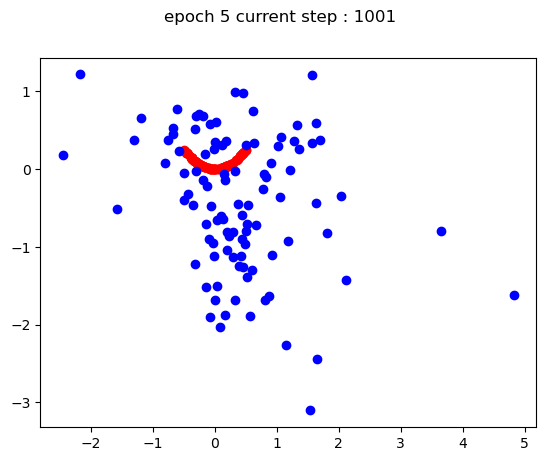

Step 1000: Generator loss: -0.41213253208994866, crtic loss: 6.1039826784133915
Memory usage (RSS): 353.5625 MB
aedwip len(generatorLosses) : 1001
aedwip numExamples : 1001


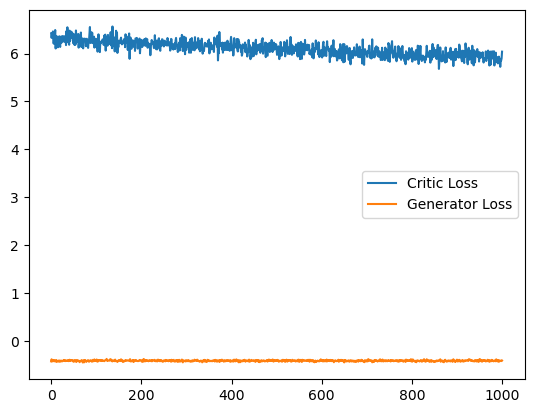

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch010.png


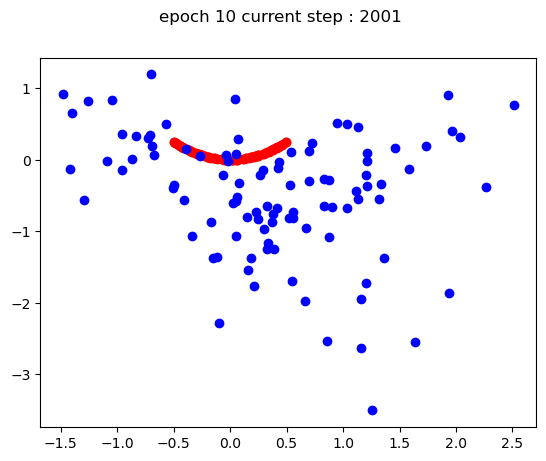

Step 2000: Generator loss: -0.4132951230108738, crtic loss: 5.7191459121704105
Memory usage (RSS): 357.80078125 MB
aedwip len(generatorLosses) : 2001
aedwip numExamples : 2001


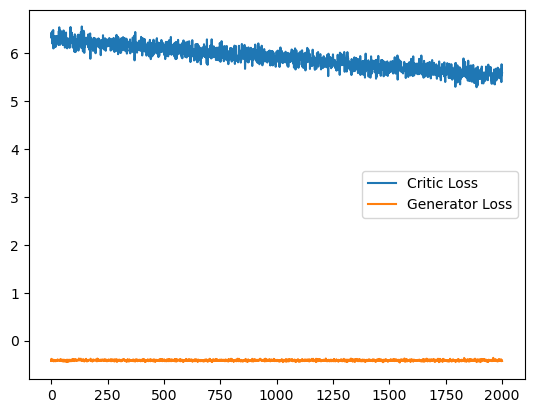

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch015.png


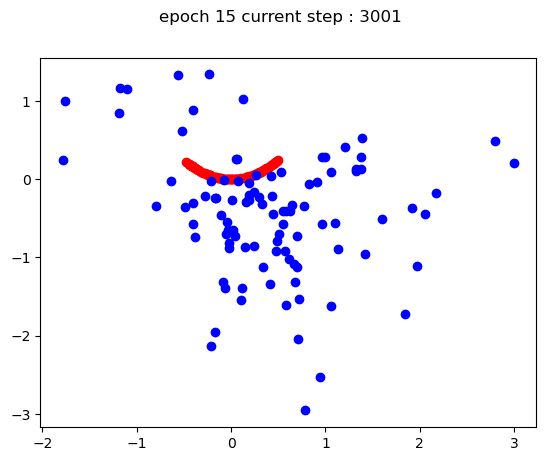

Step 3000: Generator loss: -0.41379741457104685, crtic loss: 5.361251934528351
Memory usage (RSS): 358.56640625 MB
aedwip len(generatorLosses) : 3001
aedwip numExamples : 3001


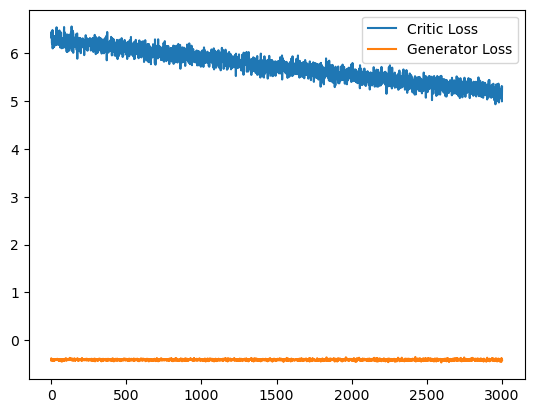

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch020.png


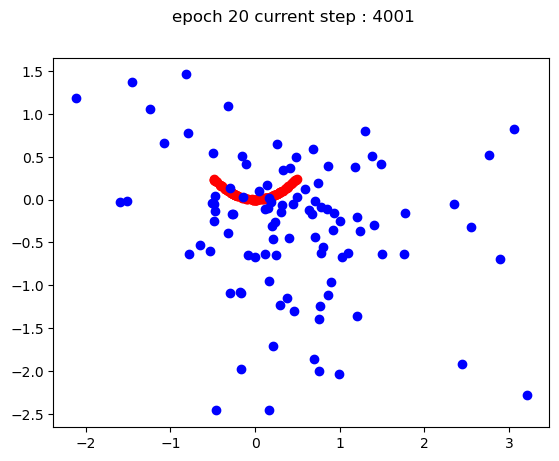

Step 4000: Generator loss: -0.4141483868956566, crtic loss: 5.03084343624115
Memory usage (RSS): 360.6640625 MB
aedwip len(generatorLosses) : 4001
aedwip numExamples : 4001


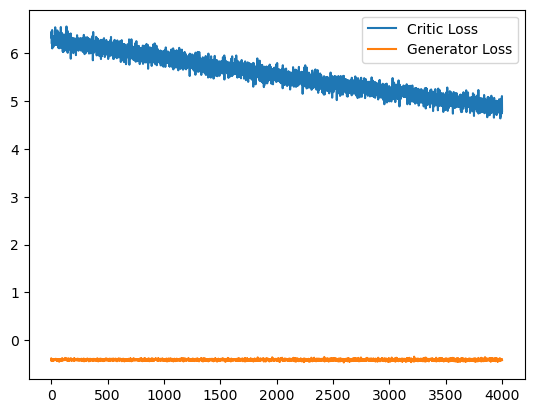

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch025.png


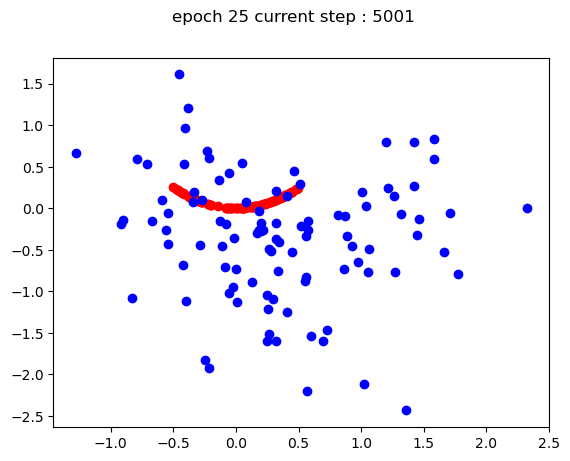

Step 5000: Generator loss: -0.41449574783444404, crtic loss: 4.717799110889435
Memory usage (RSS): 362.1640625 MB
aedwip len(generatorLosses) : 5001
aedwip numExamples : 5001


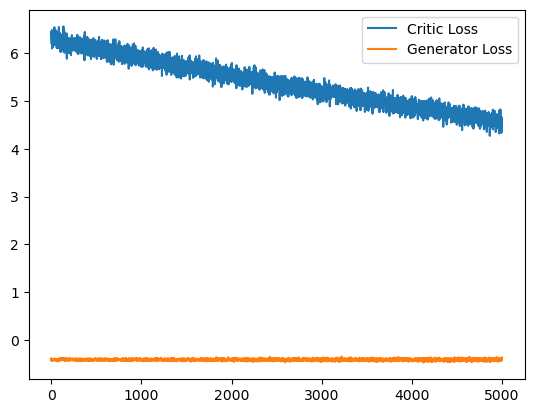

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch030.png


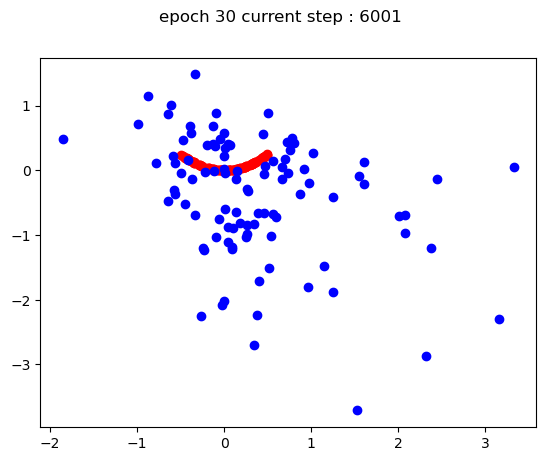

Step 6000: Generator loss: -0.413992083132267, crtic loss: 4.430331282615661
Memory usage (RSS): 363.70703125 MB
aedwip len(generatorLosses) : 6001
aedwip numExamples : 6001


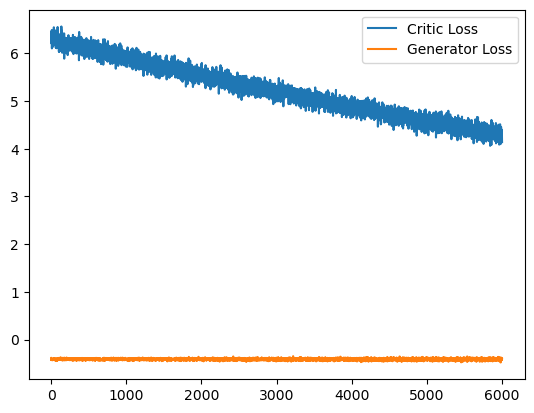

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch035.png


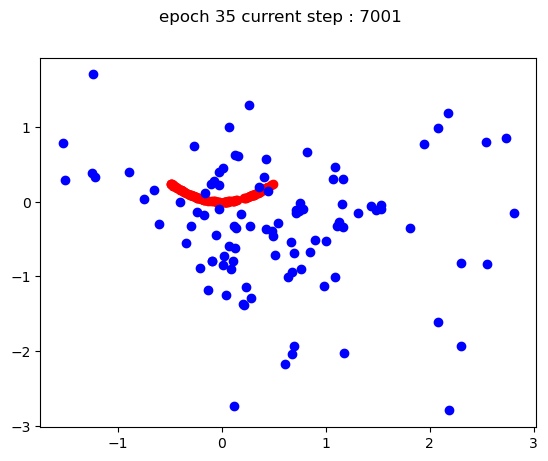

Step 7000: Generator loss: -0.4136943766474724, crtic loss: 4.1555936460495
Memory usage (RSS): 363.71875 MB
aedwip len(generatorLosses) : 7001
aedwip numExamples : 7001


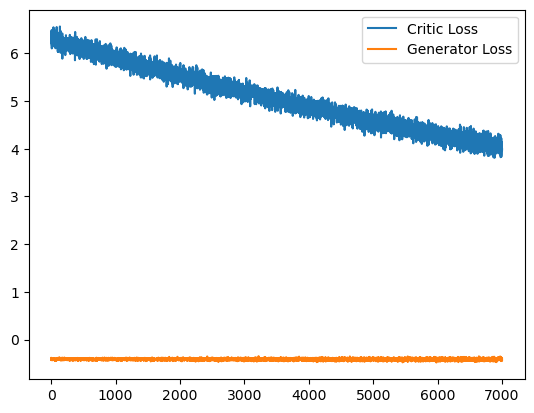

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch040.png


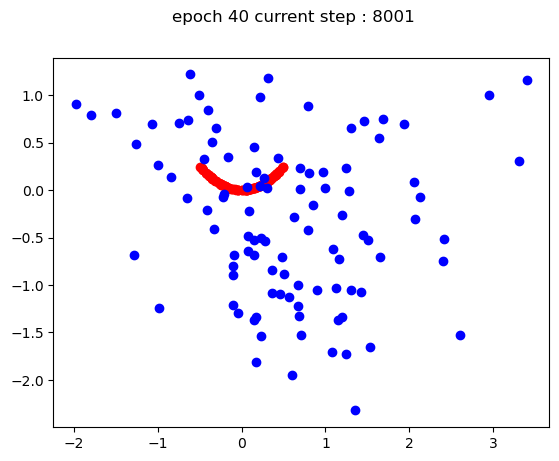

Step 8000: Generator loss: -0.4126601312756538, crtic loss: 3.893148428440094
Memory usage (RSS): 363.75390625 MB
aedwip len(generatorLosses) : 8001
aedwip numExamples : 8001


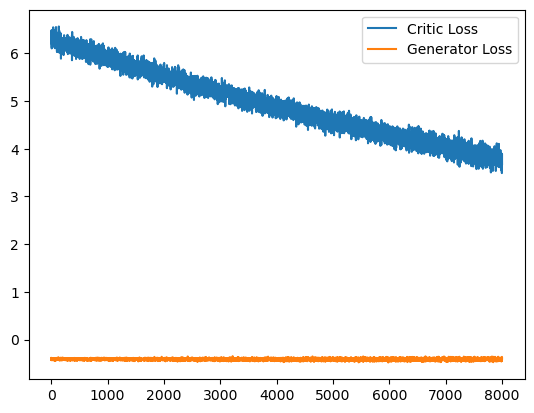

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch045.png


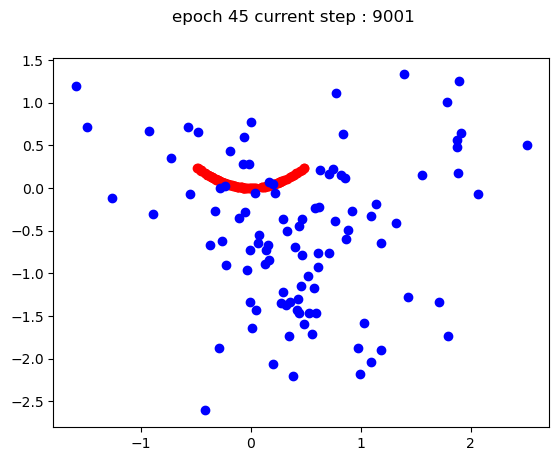

Step 9000: Generator loss: -0.4116213099062443, crtic loss: 3.645332065343857
Memory usage (RSS): 367.4609375 MB
aedwip len(generatorLosses) : 9001
aedwip numExamples : 9001


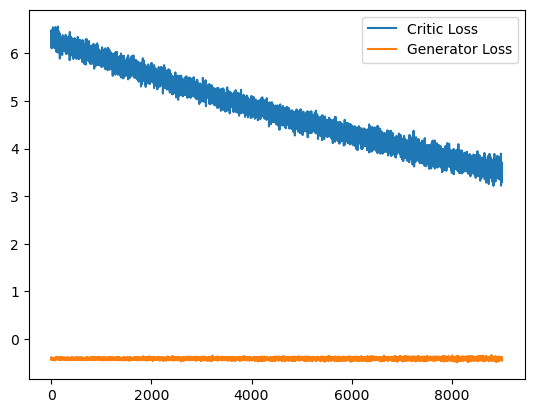

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch050.png


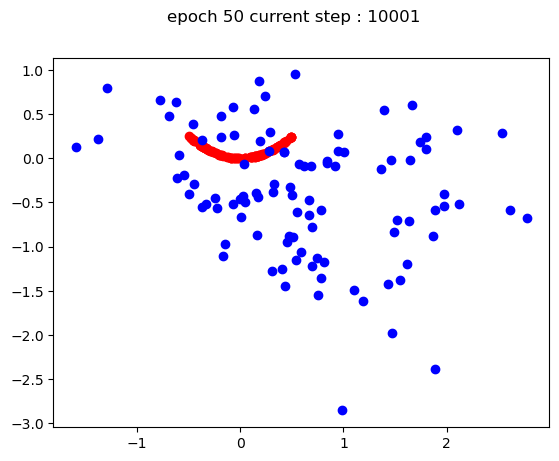

Step 10000: Generator loss: -0.41039741843938826, crtic loss: 3.429524003267288
Memory usage (RSS): 372.32421875 MB
aedwip len(generatorLosses) : 10001
aedwip numExamples : 10001


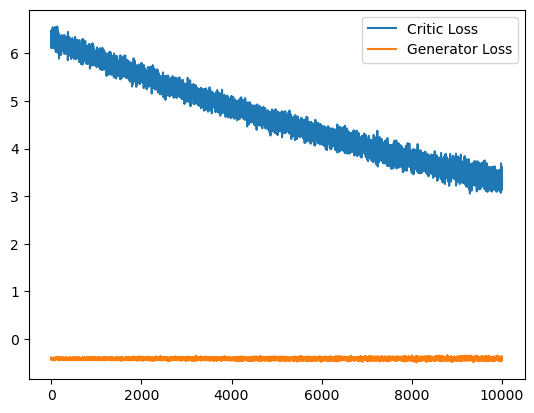

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch055.png


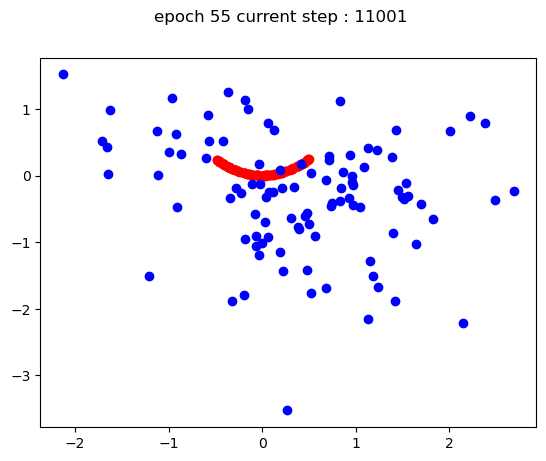

Step 11000: Generator loss: -0.40986433839797975, crtic loss: 3.221931576490402
Memory usage (RSS): 377.9296875 MB
aedwip len(generatorLosses) : 11001
aedwip numExamples : 11001


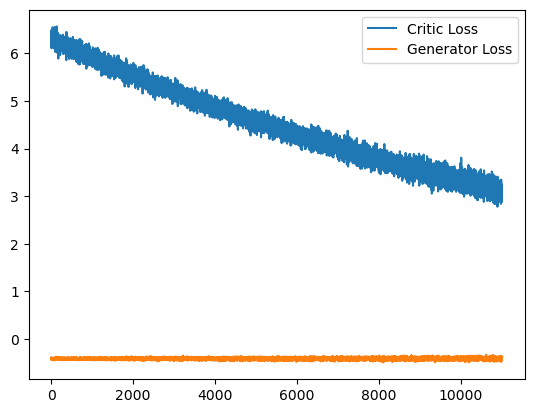

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch060.png


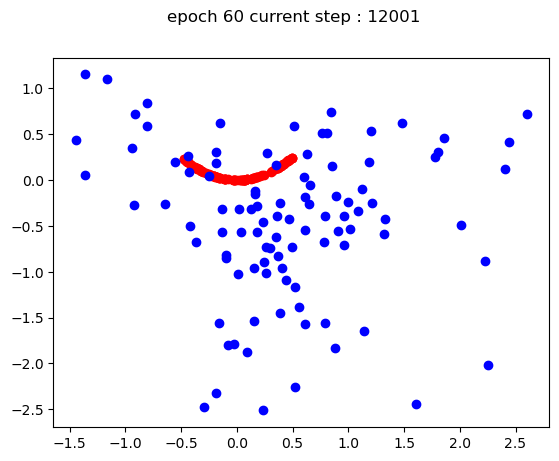

Step 12000: Generator loss: -0.4102442755997181, crtic loss: 3.026213401556015
Memory usage (RSS): 383.890625 MB
aedwip len(generatorLosses) : 12001
aedwip numExamples : 12001


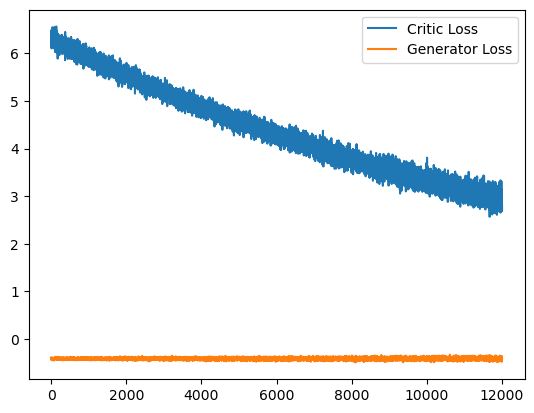

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch065.png


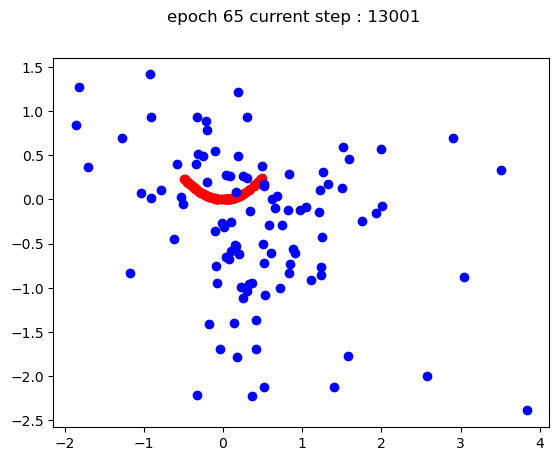

Step 13000: Generator loss: -0.4078243823945522, crtic loss: 2.8388469269275665
Memory usage (RSS): 390.68359375 MB
aedwip len(generatorLosses) : 13001
aedwip numExamples : 13001


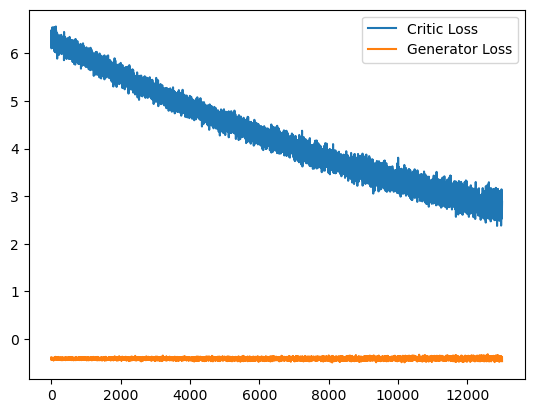

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch070.png


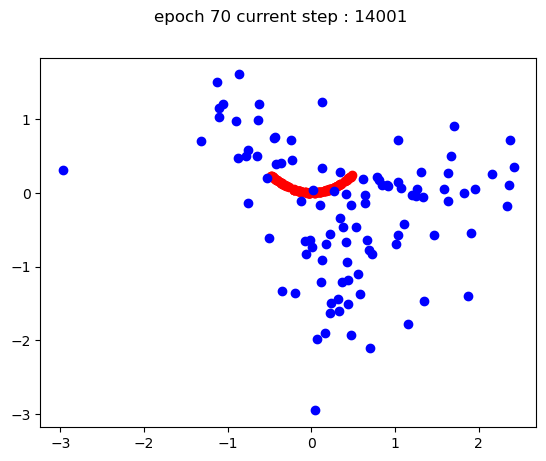

Step 14000: Generator loss: -0.40650432255864144, crtic loss: 2.66562801861763
Memory usage (RSS): 397.69921875 MB
aedwip len(generatorLosses) : 14001
aedwip numExamples : 14001


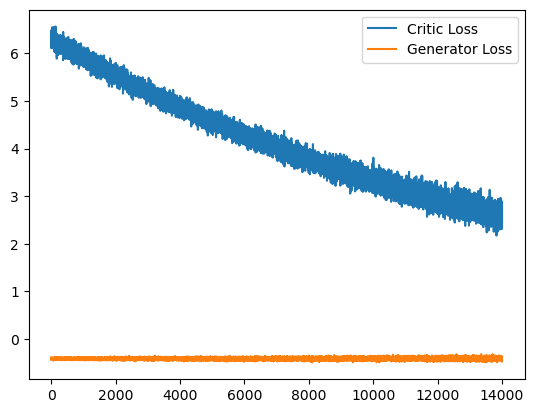

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch075.png


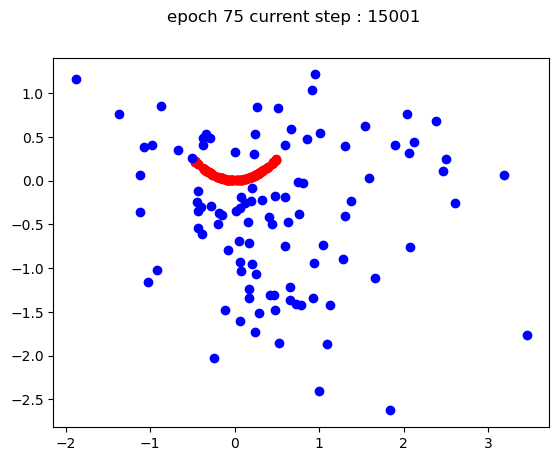

Step 15000: Generator loss: -0.40581772091984747, crtic loss: 2.4936626214981077
Memory usage (RSS): 405.0703125 MB
aedwip len(generatorLosses) : 15001
aedwip numExamples : 15001


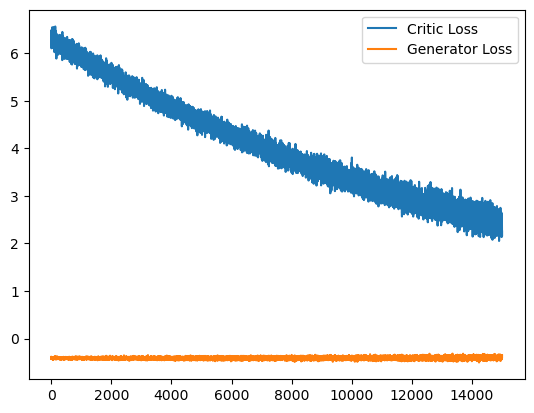

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch080.png


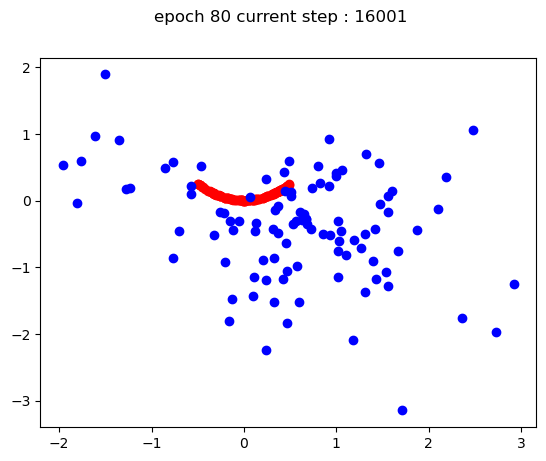

Step 16000: Generator loss: -0.40459428426623345, crtic loss: 2.3532161206007003
Memory usage (RSS): 412.90234375 MB
aedwip len(generatorLosses) : 16001
aedwip numExamples : 16001


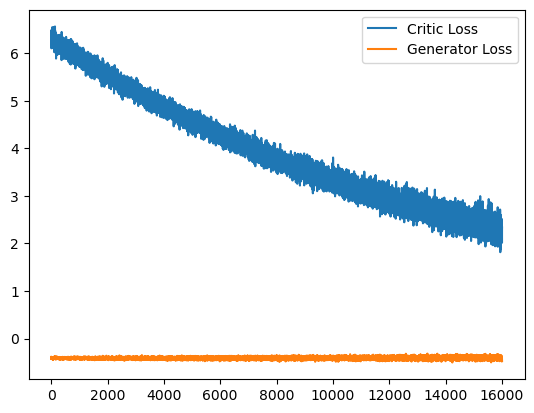

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch085.png


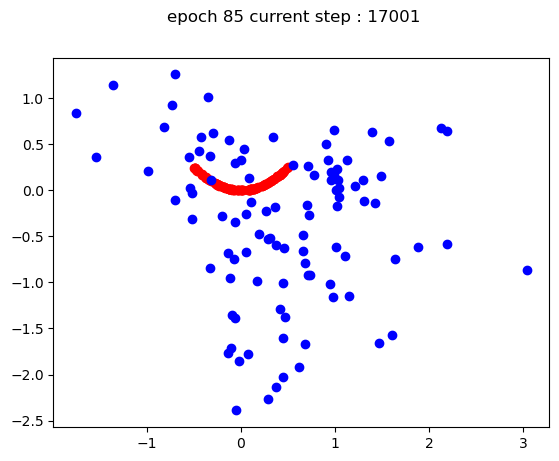

Step 17000: Generator loss: -0.4048221986591816, crtic loss: 2.2058099973201752
Memory usage (RSS): 421.3359375 MB
aedwip len(generatorLosses) : 17001
aedwip numExamples : 17001


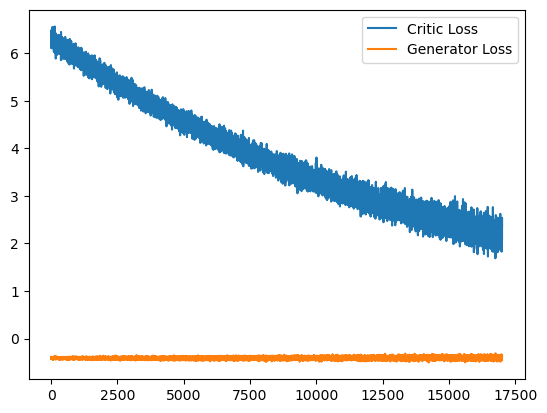

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch090.png


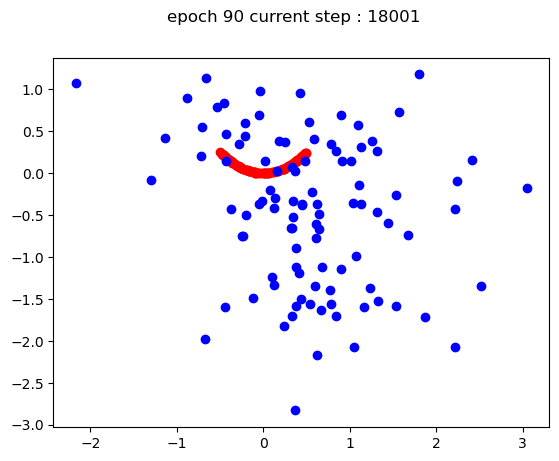

Step 18000: Generator loss: -0.4011899698376656, crtic loss: 2.058837254524231
Memory usage (RSS): 430.04296875 MB
aedwip len(generatorLosses) : 18001
aedwip numExamples : 18001


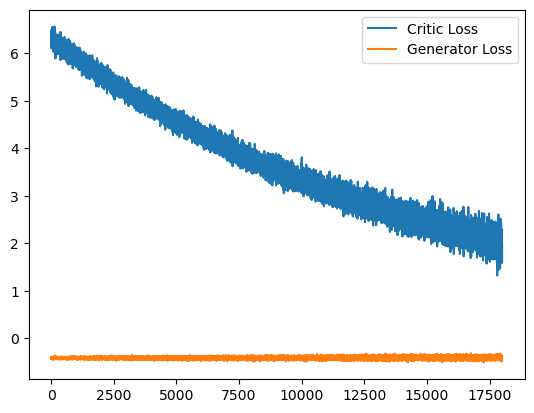

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch095.png


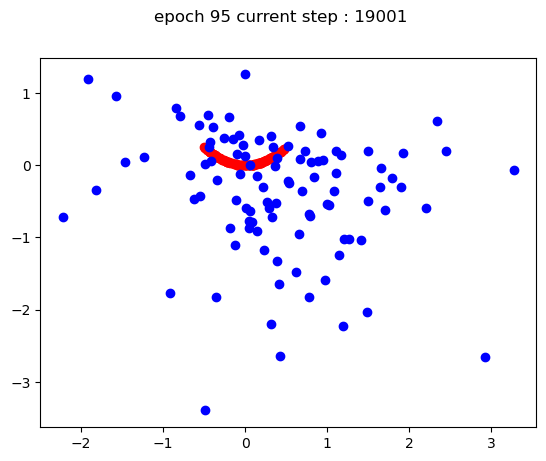

Step 19000: Generator loss: -0.39798276871442795, crtic loss: 1.9308991976976395
Memory usage (RSS): 438.9921875 MB
aedwip len(generatorLosses) : 19001
aedwip numExamples : 19001


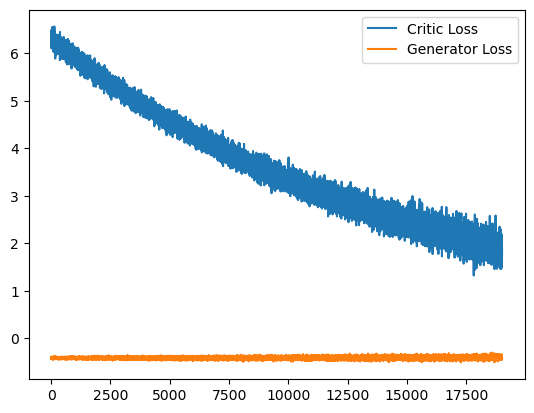

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch100.png


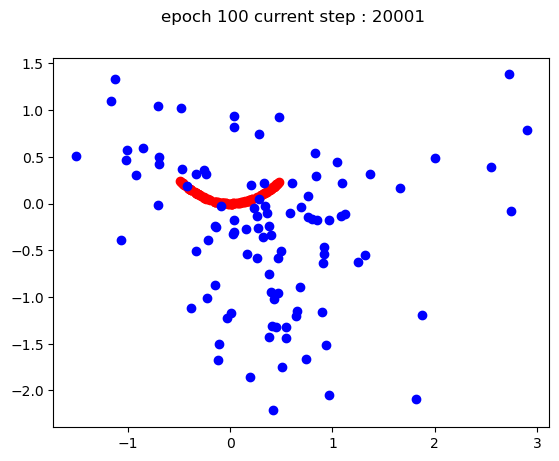

Step 20000: Generator loss: -0.3991156287789345, crtic loss: 1.8251382147073745
Memory usage (RSS): 448.82421875 MB
aedwip len(generatorLosses) : 20001
aedwip numExamples : 20001


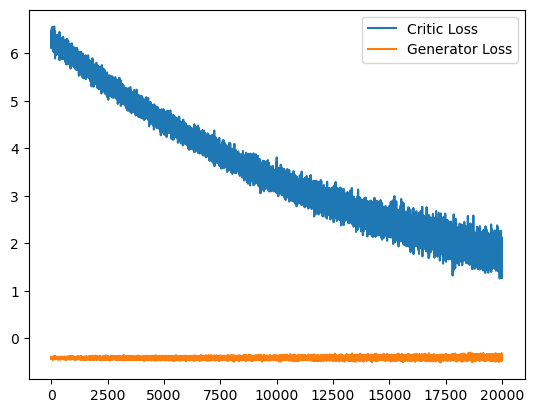

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch105.png


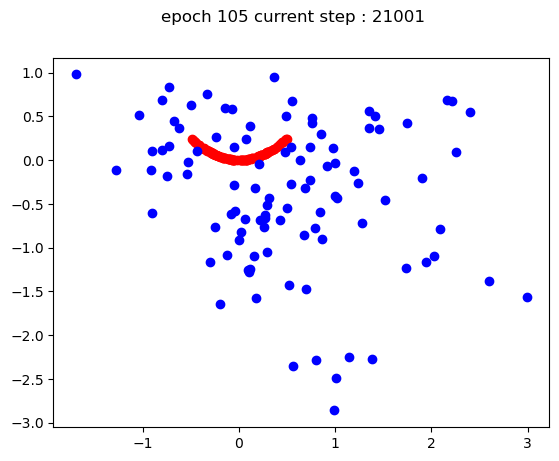

Step 21000: Generator loss: -0.39788814187049865, crtic loss: 1.7122499331235885
Memory usage (RSS): 458.59765625 MB
aedwip len(generatorLosses) : 21001
aedwip numExamples : 21001


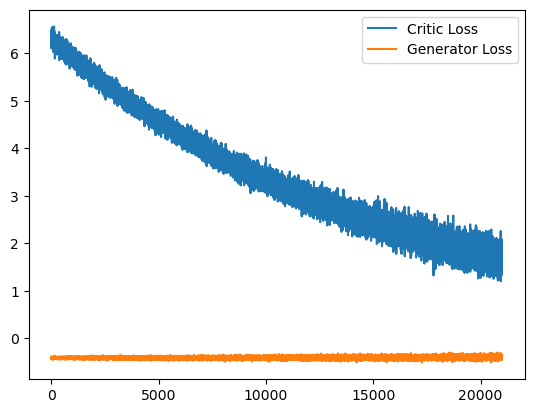

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch110.png


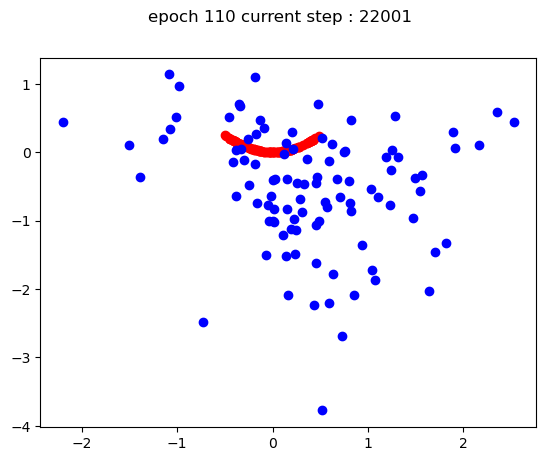

Step 22000: Generator loss: -0.3972941341996193, crtic loss: 1.6150349737405778
Memory usage (RSS): 470.8515625 MB
aedwip len(generatorLosses) : 22001
aedwip numExamples : 22001


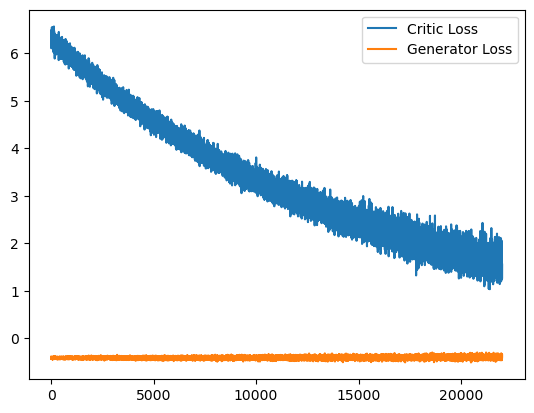

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch115.png


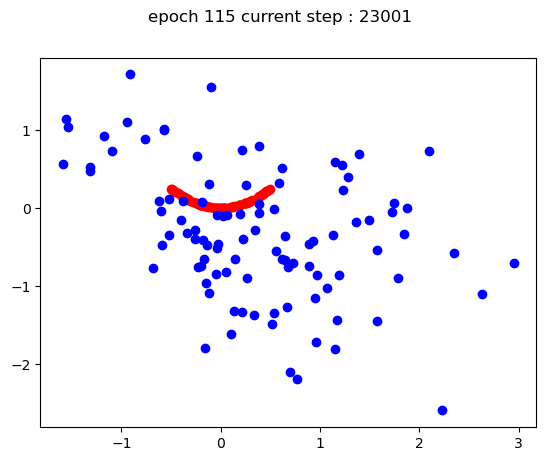

Step 23000: Generator loss: -0.3957734877765179, crtic loss: 1.5048356376886367
Memory usage (RSS): 471.75390625 MB
aedwip len(generatorLosses) : 23001
aedwip numExamples : 23001


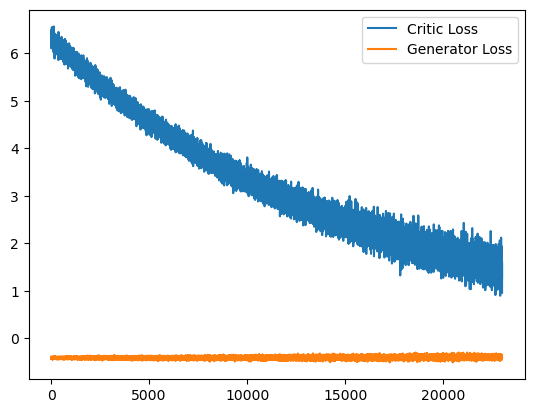

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch120.png


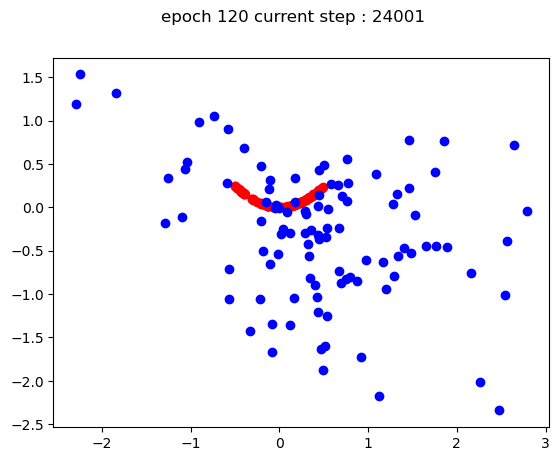

Step 24000: Generator loss: -0.39309973174333573, crtic loss: 1.4241184797883033
Memory usage (RSS): 482.81640625 MB
aedwip len(generatorLosses) : 24001
aedwip numExamples : 24001


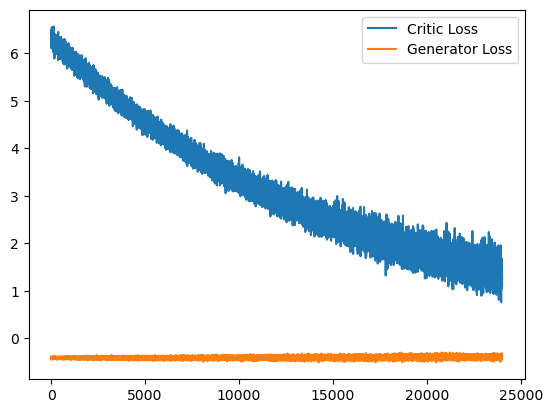

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch125.png


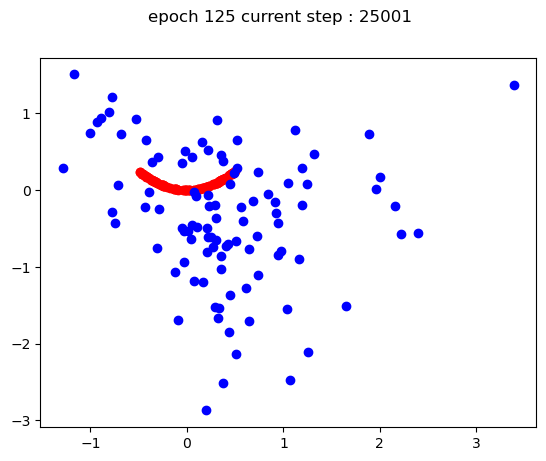

Step 25000: Generator loss: -0.39126246628165245, crtic loss: 1.342616429924965
Memory usage (RSS): 494.20703125 MB
aedwip len(generatorLosses) : 25001
aedwip numExamples : 25001


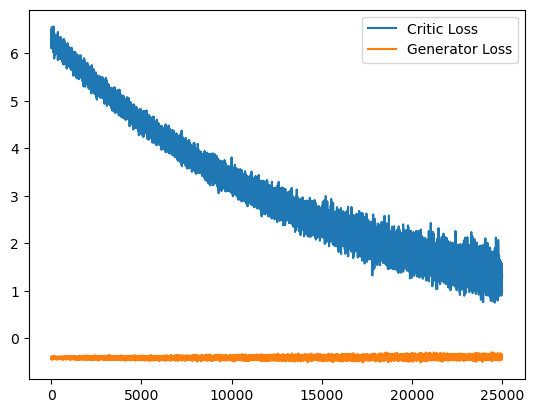

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch130.png


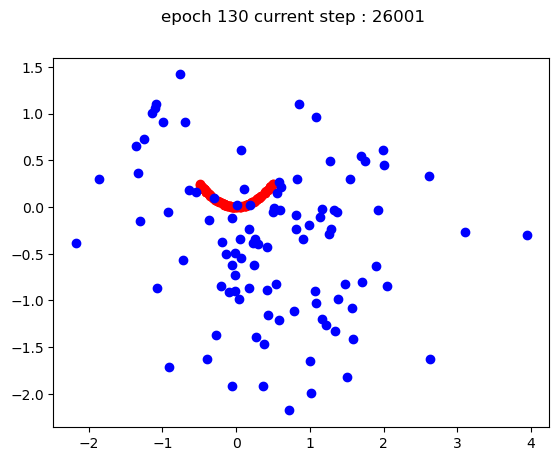

Step 26000: Generator loss: -0.3912342416644096, crtic loss: 1.267393881201744
Memory usage (RSS): 506.12109375 MB
aedwip len(generatorLosses) : 26001
aedwip numExamples : 26001


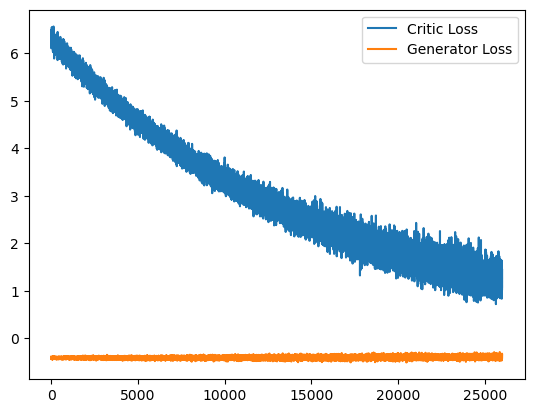

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch135.png


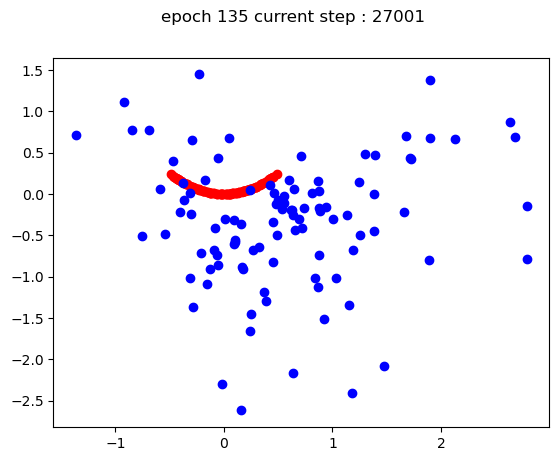

Step 27000: Generator loss: -0.390828775793314, crtic loss: 1.1867879357337952
Memory usage (RSS): 518.38671875 MB
aedwip len(generatorLosses) : 27001
aedwip numExamples : 27001


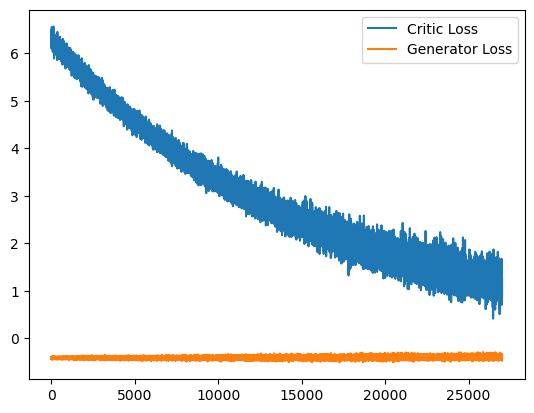

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch140.png


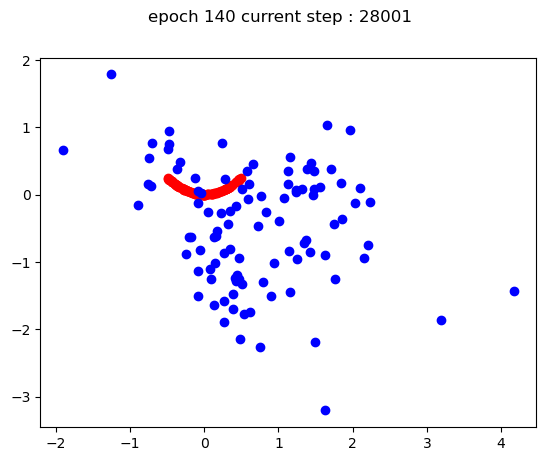

Step 28000: Generator loss: -0.39143492171168326, crtic loss: 1.1399750216007232
Memory usage (RSS): 503.4765625 MB
aedwip len(generatorLosses) : 28001
aedwip numExamples : 28001


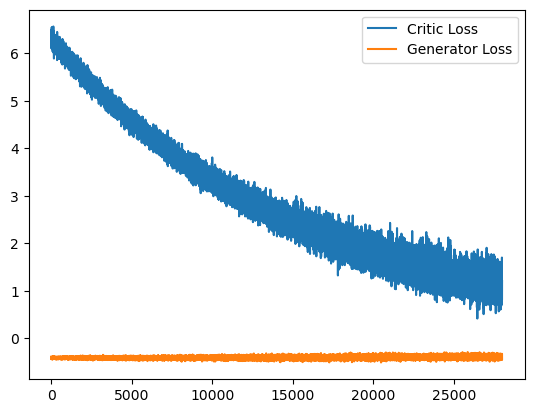

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch145.png


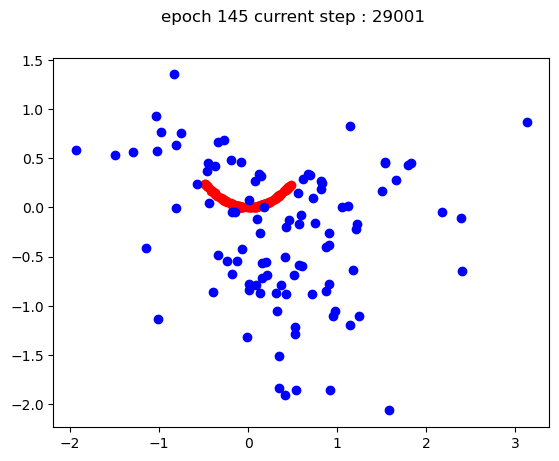

Step 29000: Generator loss: -0.39134865057468415, crtic loss: 1.081403409332037
Memory usage (RSS): 503.4765625 MB
aedwip len(generatorLosses) : 29001
aedwip numExamples : 29001


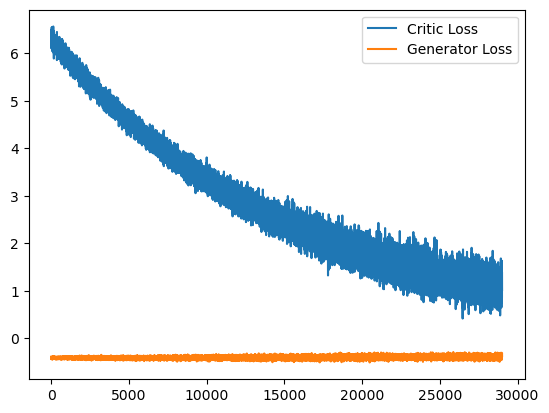

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch150.png


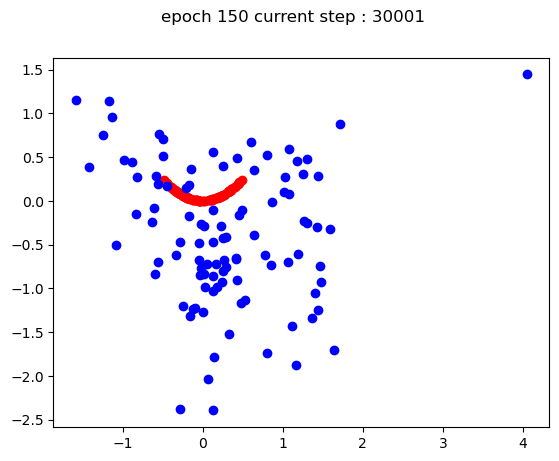

Step 30000: Generator loss: -0.39003050976991654, crtic loss: 1.016534698188305
Memory usage (RSS): 503.4765625 MB
aedwip len(generatorLosses) : 30001
aedwip numExamples : 30001


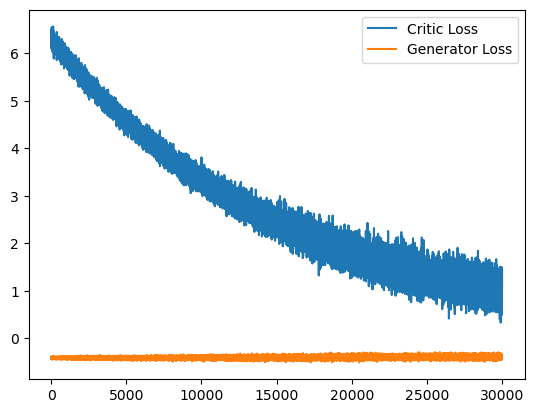

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch155.png


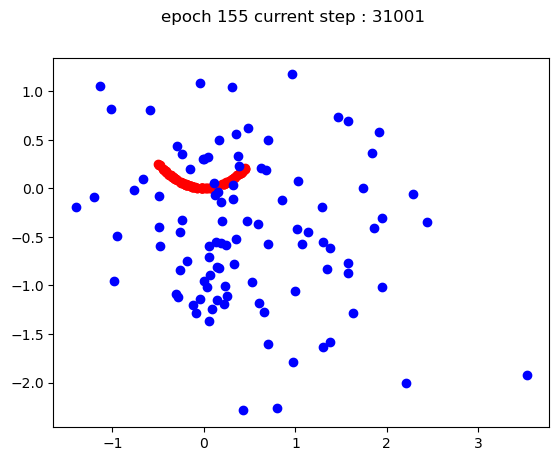

Step 31000: Generator loss: -0.39158143183588984, crtic loss: 0.9534678236842156
Memory usage (RSS): 503.4765625 MB
aedwip len(generatorLosses) : 31001
aedwip numExamples : 31001


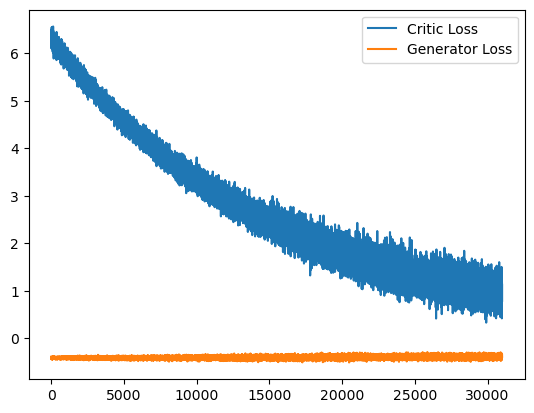

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch160.png


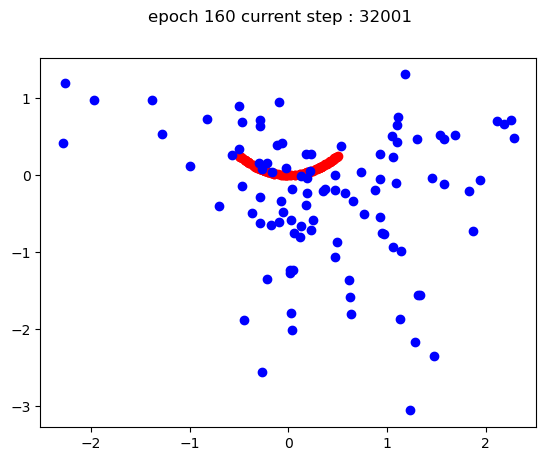

Step 32000: Generator loss: -0.3920069060921669, crtic loss: 0.9153554182052612
Memory usage (RSS): 503.4765625 MB
aedwip len(generatorLosses) : 32001
aedwip numExamples : 32001


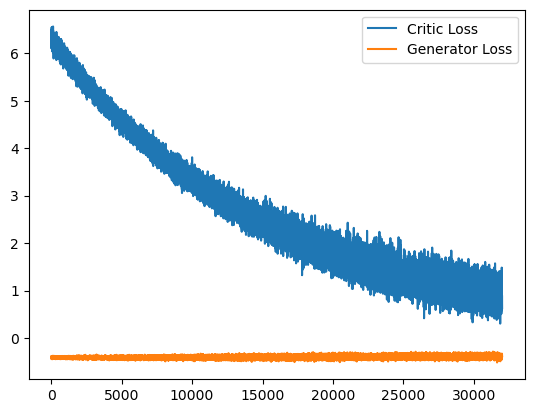

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch165.png


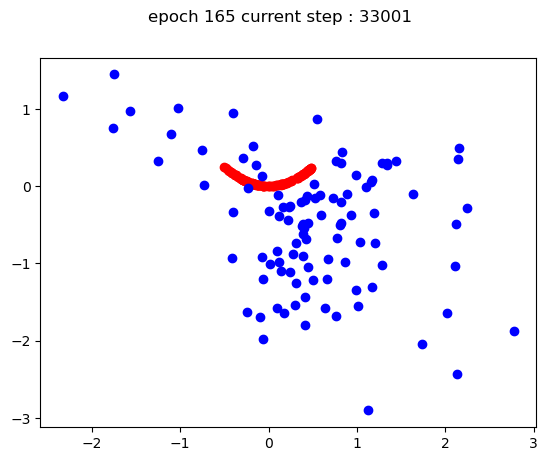

Step 33000: Generator loss: -0.3894561843574047, crtic loss: 0.881184781551361
Memory usage (RSS): 503.4765625 MB
aedwip len(generatorLosses) : 33001
aedwip numExamples : 33001


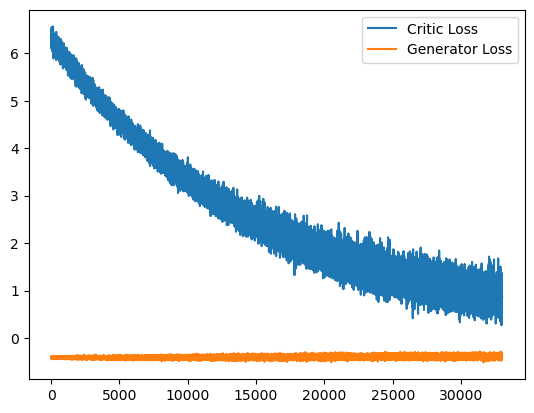

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch170.png


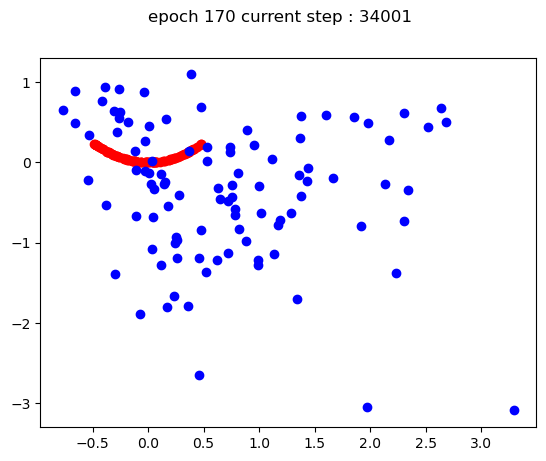

Step 34000: Generator loss: -0.3904557258784771, crtic loss: 0.8200705567002297
Memory usage (RSS): 503.96484375 MB
aedwip len(generatorLosses) : 34001
aedwip numExamples : 34001


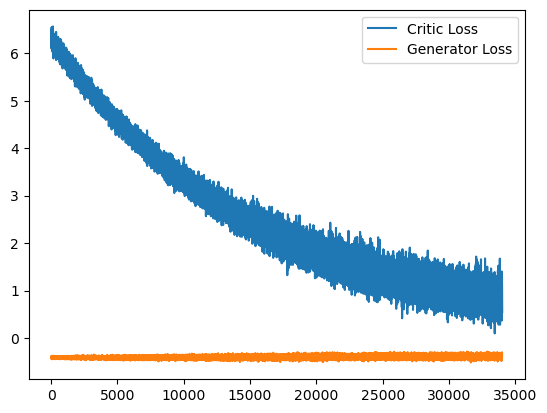

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch175.png


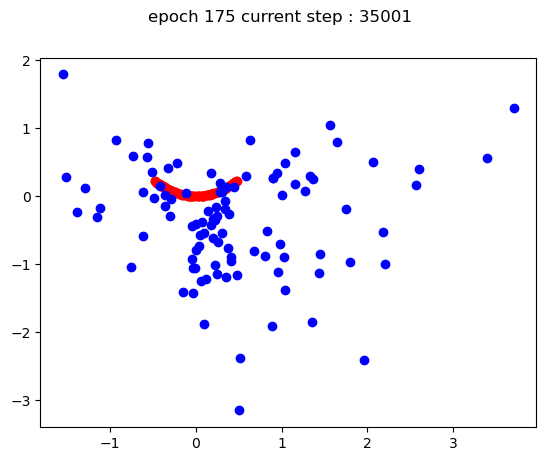

Step 35000: Generator loss: -0.3907464578747749, crtic loss: 0.7787290189564228
Memory usage (RSS): 504.015625 MB
aedwip len(generatorLosses) : 35001
aedwip numExamples : 35001


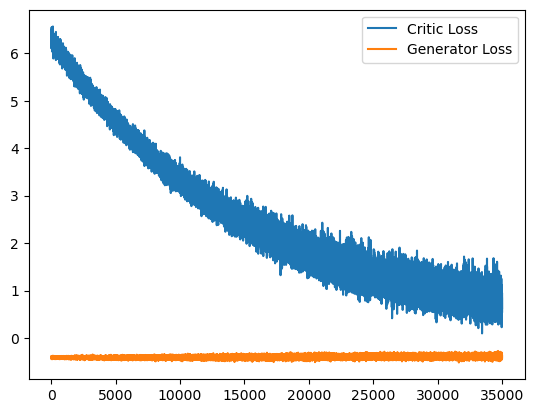

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch180.png


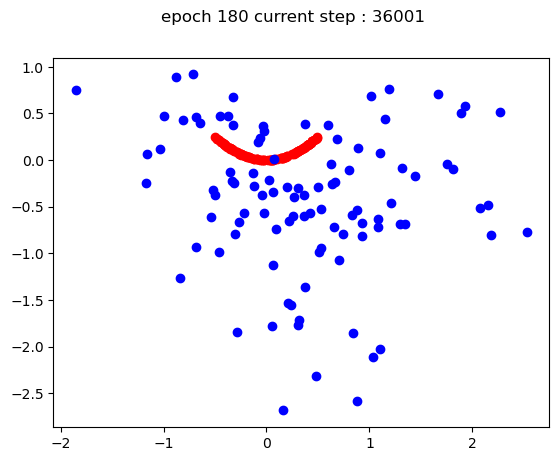

Step 36000: Generator loss: -0.39240002852678296, crtic loss: 0.7543668774366379
Memory usage (RSS): 504.015625 MB
aedwip len(generatorLosses) : 36001
aedwip numExamples : 36001


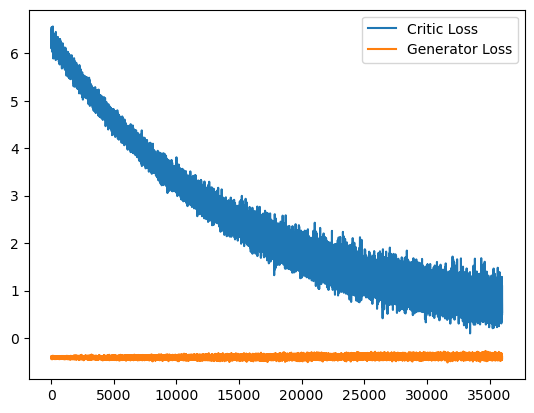

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch185.png


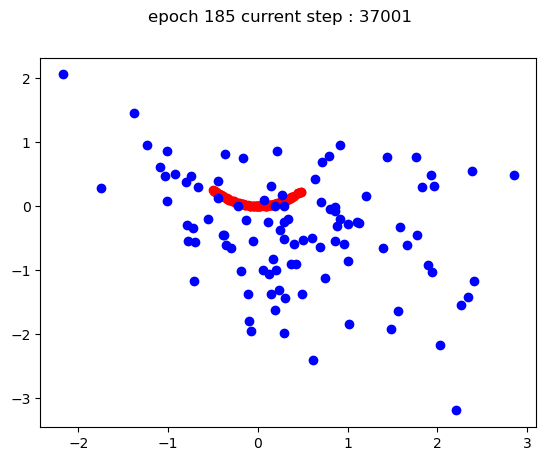

Step 37000: Generator loss: -0.392692562431097, crtic loss: 0.699175377547741
Memory usage (RSS): 504.03515625 MB
aedwip len(generatorLosses) : 37001
aedwip numExamples : 37001


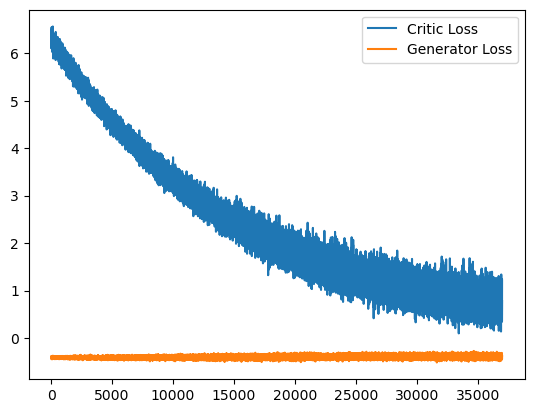

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch190.png


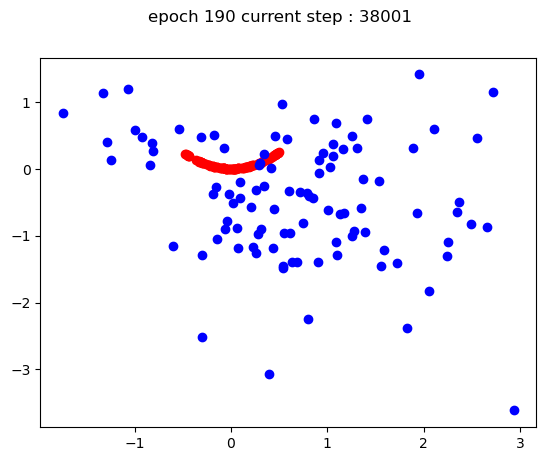

Step 38000: Generator loss: -0.39157259491086005, crtic loss: 0.6705679158568383
Memory usage (RSS): 504.03515625 MB
aedwip len(generatorLosses) : 38001
aedwip numExamples : 38001


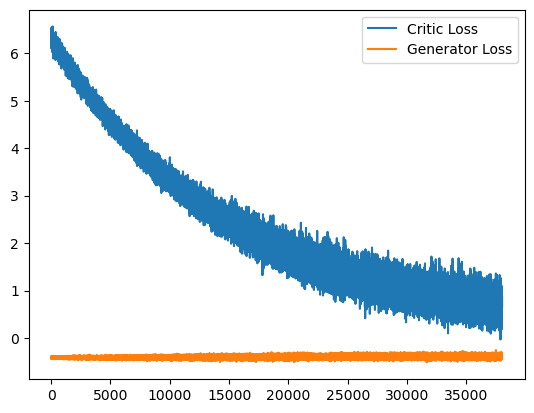

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch195.png


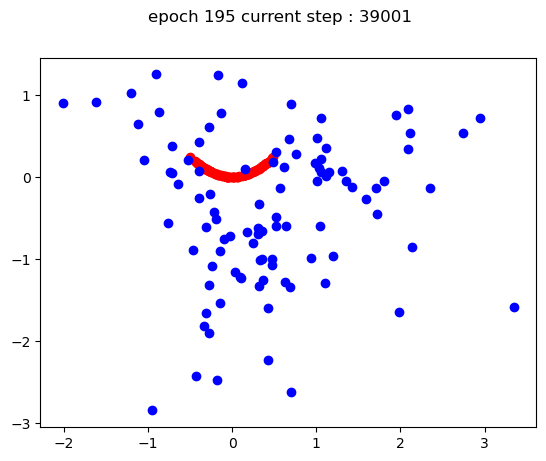

Step 39000: Generator loss: -0.3936350633203983, crtic loss: 0.6384531979262829
Memory usage (RSS): 504.03515625 MB
aedwip len(generatorLosses) : 39001
aedwip numExamples : 39001


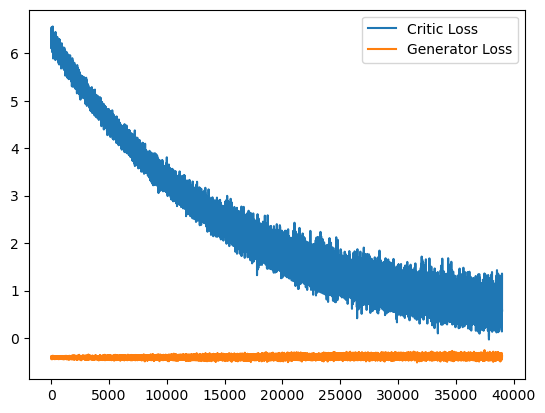

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch200.png


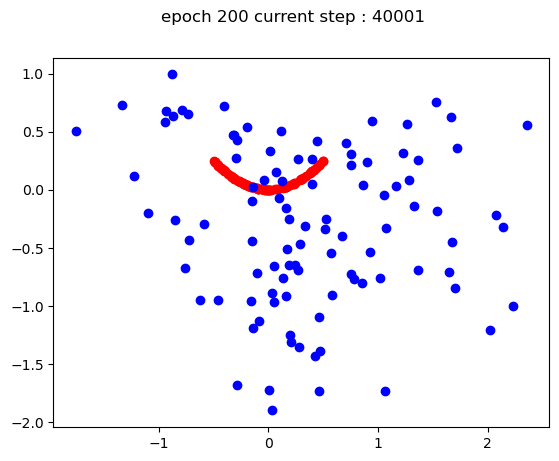

finished
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch200.png


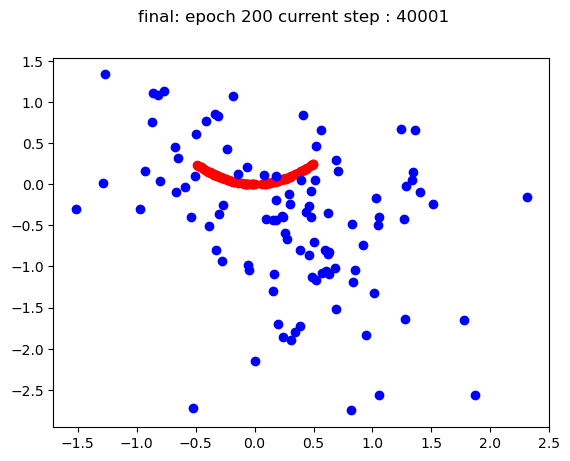

CPU times: user 9min 36s, sys: 29.4 s, total: 10min 5s
Wall time: 2min 22s


In [17]:
%%time

# reset state every time we run
currentStep = 0

# meanGeneratorLoss = 0
# meanDiscriminatorLoss = 0

generatorLosses = []
criticLosses = []

testGenerator= True # if true test generator weights are changing
error = False # default: no error


for epoch in range(nEpochs):

    #
    # add check point at end of each epoch    
    
    # tqdm provides progress bars for loops and iterables.
    # will choose implementaiton based on env. ie shell, juypter, ...
    # https://tqdm.github.io/
    # for i in tqdm( range(numBatchs) ) : 
    for i in range(numBatchs) : 
        # each epoch trains using all training samples where each sample is assigned to 
        # a random batch. After each patch update the model weights
        
        # if we where working with real data it is possible 
        # some batches are short. are < batchSize
        currentBatchSize = batchSize
        realSamples, realLabels = generateRealSamples( currentBatchSize )

        #################        
        ################# Update critic 
        #################        
        meanIterationCriticLoss = 0
        for _ in range( criticRepeats ):
            # update the critic multiple times every time you update the generator This helps 
            # prevent the generator from overpowering the critic. Sometimes, you might see the 
            # reverse, with the generator updated more times than the critic. This depends on 
            # architectural (e.g. the depth and width of the network) and algorithmic 
            # choices (e.g. which loss you're using).

            # Zero out the gradients before backpropagation
            criticOptimizer.zero_grad()

            fakeSamples, fakeLabels  = generateFakeSamples( generator, zDim, currentBatchSize, device )

            predictionsOnFakes = critic( fakeSamples )
            predictionsOnReal = critic( realSamples )

            epsilon = torch.rand( len(realSamples), 1, device=device, requires_grad=True )
            #print(f'aedwip epsilon.shape: {epsilon.shape}')
            #print(f'aedwip epsilon: {epsilon}')
            
            gradient = getGradient( critic, realSamples, fakeSamples.detach(), epsilon )
            gp = gradientPenalty( gradient )
            criticLoss = getCriticLoss( predictionsOnFakes, predictionsOnReal, gp, cLambda )

            # Keep track of the average critic loss in this batch
            meanIterationCriticLoss += criticLoss.item() / criticRepeats
            
            # Update gradients
            criticLoss.backward(retain_graph=True)
            
            # Update optimizer
            criticOptimizer.step()

        # concatenate the list items
        #print(f'aedwip meanIterationCriticLoss : {meanIterationCriticLoss}' )        
        criticLosses += [meanIterationCriticLoss]

        #################        
        ################# Update critic 
        #################        
        generatorOptimizer.zero_grad()
        fakeSamples2, fakeLabels2  = generateFakeSamples( generator, zDim, currentBatchSize, device )

        predictionsOnFakes2 = critic( fakeSamples2 )

        generatorLoss = getGeneratorLoss( predictionsOnFakes2 )
        generatorLoss.backward()

        # Update the weights
        generatorOptimizer.step()

        # Keep track of the average generator loss
        # concatenate the lists
        #print(f'aedwip generatorLoss.item() : {generatorLoss.item()}' )
        generatorLosses += [generatorLoss.item()]

        

        ### Visualization code ###
        if currentStep % displayStep == 0 and currentStep > 0:
            genMean = sum(generatorLosses[-displayStep:]) / displayStep
            criticMean = sum(criticLosses[-displayStep:]) / displayStep            
            msg = f'Step {currentStep}: Generator loss: {genMean}, crtic loss: {criticMean}'
            print( msg )

            # Get memory usage of the current process in bytes
            process = psutil.Process()
            memory_info = process.memory_info()
            rss_memory = memory_info.rss  # Resident Set Size (physical memory used)
            print("Memory usage (RSS):", rss_memory / (1024 * 1024), "MB")   
            
            #
            # plot learning curves
            # 
            stepBins = 1 # this does some smoothing 20 # AEDWIP
            numExamples = (len(generatorLosses) // stepBins) * stepBins
            print(f'aedwip len(generatorLosses) : {len(generatorLosses)}' )
            print(f'aedwip numExamples : {numExamples}' )

            plt.plot(
                range(numExamples // stepBins), 
                torch.Tensor(criticLosses[:numExamples]).view(-1, stepBins).mean(1),
                label="Critic Loss"
            )
            plt.plot(
                range(numExamples // stepBins), 
                torch.Tensor(generatorLosses[:numExamples]).view(-1, stepBins).mean(1),
                label="Generator Loss"
            )
            
            plt.legend()
            plt.show()        
            
        currentStep += 1

        
        #if (epoch + 1) % displayQuotient == 0 and currentStep > 0:
        if currentStep % plotStep == 0 and currentStep > 0:
            title = f"epoch {epoch + 1} current step : {currentStep + 1}"
            summarizePerformance(generator, zDim, imgOut, title)


print(f'finished')
title = f"final: epoch {epoch + 1} current step : {currentStep + 1}"
summarizePerformance(generator, zDim, imgOut, title)
#print(f"Step {currentStep}: Generator loss: {meanDiscriminatorLoss}, discriminator loss: {meanGeneratorLoss}")
if error :
    print( f'ERROR occured. Review output' )